# Molecular visualisation

```{admonition} Learning outcomes
After working through this topic, you should be able to:

1. draw one or more small molecules as structural formulae with RDKit
2. highlight selected atoms or structural patterns in a molecular drawing
3. generate a possible three-dimensional conformer from a SMILES string and explain the limitations of the model
4. display proteins with `nglview` and select specific parts of a structure
5. add molecular surfaces and explain what the surface represents
6. visualise a molecular-dynamics trajectory as an animation
7. choose a representation that fits the chemical question
```

So far, we have mainly represented molecules using text and numbers: SMILES strings, molecular formulae and calculated properties. Visualisation gives us a different kind of information. We can inspect connectivity, molecular shape, functional groups, enzyme active sites and molecular motion.

A visualisation is a **model**. It emphasises some properties and hides others. A 2D structural formula shows bonding and functional groups clearly but says little about three-dimensional shape. A 3D representation shows shape but can make bond order and some structural details harder to see.

In this chapter the libraries have different roles:

- RDKit is used for small molecules: SMILES, 2D drawings, substructure patterns and generation of 3D conformers.
- `nglview` is used for interactive 3D visualisation of molecules, proteins and simulations.

## Installation

Run the following cell once. `nglview` is a **widget**: the interactive figure is connected to a running Python kernel rather than being an ordinary static image. In VS Code, the widget should appear directly below the code cell.

Older tutorials sometimes contain extra commands for enabling `nglview` as a notebook extension. These are usually unnecessary in current Jupyter environments.

In [ ]:
!pip install nglview rdkit mdtraj

## Where do molecular structures come from?

Small and large molecules are commonly represented in different ways.

| Representation | Typical use | What it stores |
|---|---|---|
| SMILES | small molecules | molecular graph encoded as text |
| Mol/SDF files | small molecules | atoms, bonds and optionally coordinates |
| PDB/mmCIF | proteins and other macromolecular structures | atom identities, residues and measured/modelled coordinates |
| trajectory files | molecular dynamics | coordinates for many successive frames |

A coordinate file is not an unfiltered picture of reality. Protein structures may come from X-ray crystallography, NMR, cryo-EM or prediction, and each method has assumptions and uncertainties. Similarly, a generated conformer is a plausible model, not proof that the molecule adopts exactly that geometry in solution.

## Small molecules with RDKit

### Draw a structural formula

`Chem.MolFromSmiles` reads a SMILES string and constructs a molecular graph containing atoms, bonds and bond orders.

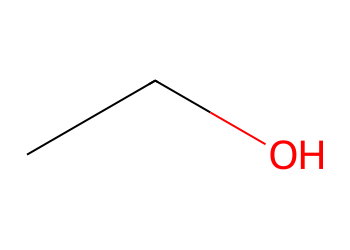

In [17]:
from rdkit import Chem
from rdkit.Chem import Draw

ethanol = Chem.MolFromSmiles("CCO")
Draw.MolToImage(ethanol, size=(350, 250))

This is a **2D representation**. The positions of the atoms on the page are chosen to make the molecular graph readable; the drawing is not a projection of one experimentally observed 3D conformation.

### Several molecules in one figure

When we want to compare structures, `Draw.MolsToGridImage` is convenient.

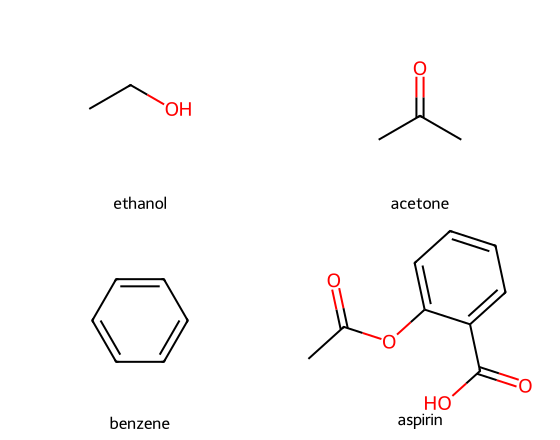

In [18]:
smiles = {
    "ethanol": "CCO",
    "acetone": "CC(=O)C",
    "benzene": "c1ccccc1",
    "aspirin": "CC(=O)OC1=CC=CC=C1C(=O)O",
}

names = list(smiles)
molecules = [Chem.MolFromSmiles(smiles[name]) for name in names]
Draw.MolsToGridImage(molecules, molsPerRow=2, legends=names, subImgSize=(280, 220))

### Highlight a structural pattern

RDKit can highlight atoms that match a SMARTS pattern. Here we highlight the carboxylic-acid group in aspirin.

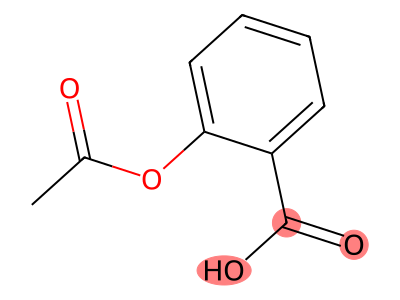

In [19]:
aspirin = Chem.MolFromSmiles(smiles["aspirin"])
carboxylic_acid = Chem.MolFromSmarts("C(=O)[OH]")
match = aspirin.GetSubstructMatch(carboxylic_acid)

Draw.MolToImage(aspirin, highlightAtoms=list(match), size=(400, 300))

```{admonition} Check your understanding
:class: tip
Change the SMARTS pattern so that you highlight the ester group in aspirin instead. Which atoms belong to both visual motifs, if any?
```
```{admonition} Suggested approach
:class: tip, dropdown
An ester can be represented with a pattern such as `C(=O)O[#6]`. Construct it with `Chem.MolFromSmarts`, obtain the match with `GetSubstructMatch`, and pass the atom indices to `highlightAtoms`. Remember that a SMARTS pattern encodes a definition chosen by us; the program is not independently deciding what counts as an ester.
```

### Generate a possible 3D conformer

A SMILES string describes connectivity. RDKit can generate 3D coordinates by embedding the molecular graph and then optimise the geometry using a molecular-mechanics force field.

In [20]:
from rdkit.Chem import AllChem

ethanol_3d = Chem.AddHs(Chem.MolFromSmiles("CCO"))
AllChem.EmbedMolecule(ethanol_3d, randomSeed=42)
AllChem.MMFFOptimizeMolecule(ethanol_3d)

0

We can pass the RDKit molecule to `nglview` for interactive viewing.

In [21]:
import nglview as nv

ethanol_view = nv.show_rdkit(ethanol_3d)
ethanol_view

NGLWidget()

```{admonition} Important limitation
A generated conformer is one plausible low-energy geometry according to the embedding and force-field procedure. Flexible molecules can have many conformers, and solvent, temperature and intermolecular interactions can alter their populations. A single 3D picture should therefore not be described as *the* structure of a flexible molecule in solution.
```

## Proteins with nglview

For macromolecules we will use structures from the Protein Data Bank (PDB). `nv.show_pdbid` downloads and displays a structure by its PDB identifier. The following examples use pepsin (PDB `1PSN`).

In [22]:
import nglview as nv

pepsin = nv.show_pdbid("1PSN")
pepsin

NGLWidget()

The default representation is useful for exploring a structure, but a chemically informative figure usually requires a deliberate choice of representation and selection.

### Select parts of a structure

We can create a cleaner ribbon representation of the protein.

In [23]:
pepsin_cartoon = nv.show_pdbid("1PSN", default_representation=False)
pepsin_cartoon.add_cartoon(selection="protein")
pepsin_cartoon.center()
pepsin_cartoon

NGLWidget()

A ribbon/cartoon representation emphasises secondary structure and the overall fold. It does **not** show every atom. That is often an advantage when the question concerns protein architecture.

We can also display selected residues explicitly. Here we show tryptophan side chains as a licorice representation.

In [24]:
pepsin_trp = nv.show_pdbid("1PSN", default_representation=False)
pepsin_trp.add_cartoon(selection="protein")
pepsin_trp.add_licorice("TRP")
pepsin_trp.center(selection="TRP")
pepsin_trp

NGLWidget()

Hovering over atoms or residues can help identify names and residue numbers while exploring a structure.

### Molecular surfaces

A surface representation can help us think about accessibility and overall shape.

In [25]:
pepsin_surface = nv.show_pdbid("1PSN", default_representation=False)
pepsin_surface.add_cartoon(selection="protein")
pepsin_surface.add_surface(selection="protein", opacity=0.30)
pepsin_surface

NGLWidget()

The surface is a calculated representation based on atomic positions and radii. It is useful for visualising shape and pockets, but it is not an experimental photograph of a hard molecular boundary. Molecules have electron-density distributions, thermal motion and solvent interactions rather than rigid macroscopic surfaces.

We can apply a surface only to selected residues.

In [26]:
pepsin_glycine = nv.show_pdbid("1PSN")
pepsin_glycine.add_surface(selection="GLY", opacity=0.40, color="tomato")
pepsin_glycine

NGLWidget()

### Change representation

`default_representation=False` removes the automatically chosen representation so that we can build the figure ourselves. For example, a ball-and-stick model displays individual atoms and bonds more explicitly.

In [27]:
pepsin_ball_and_stick = nv.show_pdbid("1PSN", default_representation=False)
pepsin_ball_and_stick.add_representation("ball+stick", selection="protein")
pepsin_ball_and_stick

NGLWidget()

For an entire protein, ball-and-stick can become visually crowded. This illustrates an important principle: **more detail is not automatically more information**. The best representation depends on the question.

### Static images

Interactive widgets are excellent for exploration, but reports and presentations often need a static image. `nglview` can render the current view.

In [28]:
pepsin_trp.render_image()

Image(value=b'', width='99%')

The rendered image can also be saved. In some Jupyter environments this operation may depend on browser permissions.

In [29]:
pepsin_trp.download_image("pepsin.png", factor=4)  # Higher factor -> higher resolution

## Visualising simulations

So far we have looked at single structures. In a **molecular-dynamics (MD) simulation**, atomic motion is calculated over many small time steps. MD is not required background for the programming chapters, but the example shows why molecular data often consist of more than one structure.

The result is stored as a **trajectory**: a sequence of coordinate frames representing the system at different times. Trajectories can be used to investigate flexibility, conformational changes and relative motion.

Here we do not run the simulation itself. We read and visualise an existing demonstration trajectory supplied with `nglview`. The `mdtraj` library reads the trajectory format.

In [30]:
import nglview as nv
import mdtraj as md

trajectory = md.load(nv.datafiles.TRR, top=nv.datafiles.PDB)
animation = nv.show_mdtraj(trajectory, default_representation=False)
animation.add_representation("cartoon", selection="protein")
animation.layout.width = "600px"
animation.layout.height = "450px"
animation.center()

animation

NGLWidget(layout=Layout(height='450px', width='600px'), max_frame=50)

Use the play button below the widget to animate the frames. The slider lets you inspect individual frames.

Another common trajectory-analysis library is `MDAnalysis`. A comparable workflow looks like this:

```{code-block} python
import MDAnalysis as mda
from MDAnalysis.tests.datafiles import PSF, DCD

universe = mda.Universe(PSF, DCD)
protein = universe.select_atoms("protein")
animation = nv.show_mdanalysis(protein)
animation
```

```{admonition} Demonstration data are a separate package
:class: warning
`MDAnalysis.tests.datafiles` is not included in the core `MDAnalysis` package. The demonstration files are distributed in `MDAnalysisTests`, which must be installed separately. This is a common source of confusing import errors.
```

````{admonition} Check your understanding: Look at the motion
:class: tip

1. Which parts of the structure move most, and which appear comparatively rigid? What might explain the difference?
2. Add a surface and watch the animation again. Does the surface make the relevant motion easier or harder to see?
3. How many frames are present? Use `len(trajectory)`. If frames were stored every 10 ps, what total time would the trajectory cover?
4. Compare that time with a catalytic cycle that may take microseconds to milliseconds or longer. What practical limitation does this illustrate for molecular-dynamics simulations?

```{admonition} Suggested discussion
:class: tip, dropdown
Flexible loops and termini often show larger motions than tightly packed secondary-structure elements, although the exact pattern depends on the trajectory. Adding a surface may reveal changes in overall shape but can hide internal motion. A simulation can only sample processes that occur within the time and configuration space it actually explores; a short trajectory cannot by itself demonstrate a much slower event.
```
````

## Division of labour between the libraries

| Library | Main role in this chapter |
|---|---|
| RDKit | read SMILES, draw 2D structures, identify structural patterns, generate small-molecule conformers |
| `nglview` | interactive 3D display of RDKit molecules, PDB structures and trajectories |
| `mdtraj` | read and process molecular-dynamics trajectory files |

A useful workflow is:

1. **Represent or read the structure.** Use RDKit, a PDB structure or a trajectory reader.
2. **Decide what you want to show.** Bonds, a functional group, a ligand, a surface or motion?
3. **Choose a representation that answers the chemical question.**
4. **Ask what the figure does not show.** A structural image does not automatically show energy, charge distribution, kinetics or the populations of conformations in solution.

## Exercises

```{admonition} Exercise 1 — structural formulae with RDKit
:class: tip
Choose three molecules that illustrate different bonding: one containing only single bonds, one with a double bond and one aromatic molecule. Draw them in the same grid with `Draw.MolsToGridImage`, add names using `legends`, highlight one functional group with a SMARTS pattern, and explain what the 2D drawings reveal and conceal.
```

```{admonition} Exercise 2 — an enzyme and its ligand
:class: tip
Choose a PDB structure of an enzyme solved with a substrate, substrate analogue or inhibitor. Lysozyme with a bound carbohydrate (`1HEW`) is a useful starting point. Display the protein as a cartoon and the ligand as ball-and-stick or licorice. Centre the view on the ligand and identify residues close to it. What chemical question does your representation help answer?
```

```{admonition} Exercise 3 — surface versus cartoon
:class: tip
Display the same protein as (a) cartoon, (b) surface and (c) cartoon plus a semi-transparent surface. For each representation, write one question it helps answer and one important feature it hides.
```

```{admonition} Exercise 4 — generated conformers
:class: tip
Generate a 3D conformer for butane or another flexible molecule with RDKit. Repeat the embedding with several random seeds. Do you always obtain the same geometry? Explain why a single generated conformer should not be called the experimentally observed molecular structure.
```

```{admonition} Exercise 5 — trajectory visualisation
:class: tip
Load the demonstration trajectory with `mdtraj` and `nglview`. Compare a cartoon representation with a surface representation while the trajectory is playing. Which representation makes local flexibility easiest to see? Which makes changes in overall shape easiest to see?
```